SAMURAI output verification

This notebook is used to visualize the output from SAM 2 tracking results visually. It's encourged to also integrate Siamese neural Network for verification in the middle

In [0]:
%pip install matplotlib opencv-python

Multiple Frames

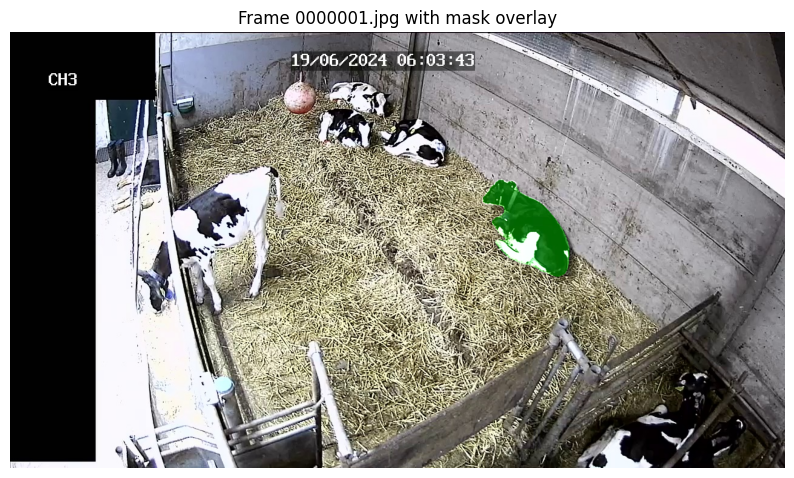

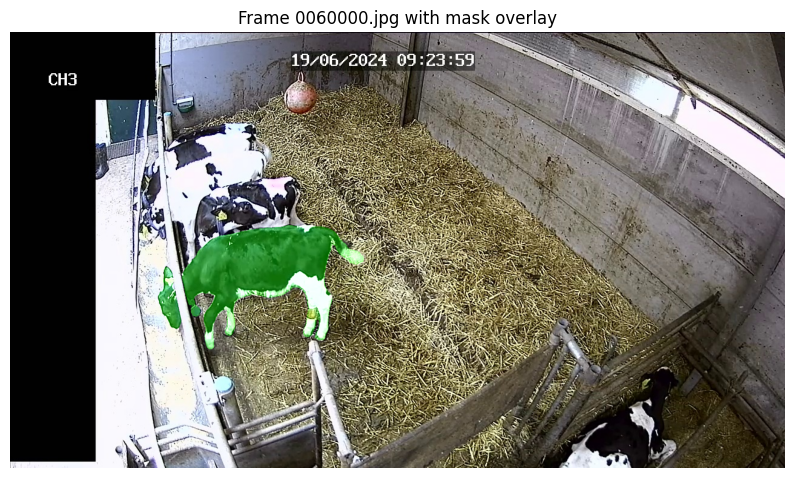

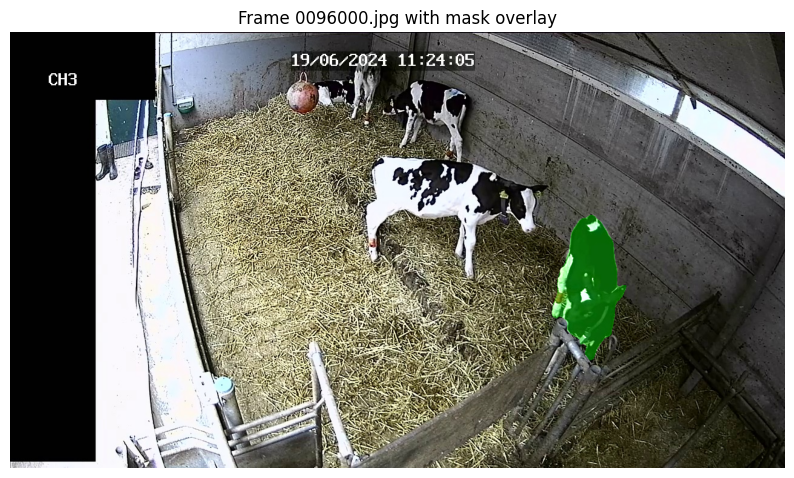

In [0]:
import os
import os.path as osp
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_mask_on_frame(frame_index, image_dir, annotation_json_path, 
                            frame_name_format="{:07d}.jpg", mask_color=(0, 255, 0), mask_opacity=0.4):
    
    # Ensure the image directory is accessible (prepend '/dbfs' if needed)
    if not image_dir.startswith("/dbfs"):
        image_dir = osp.join("/dbfs", image_dir.lstrip("/"))
    
    # Construct the frame filename and its full path.
    frame_filename = frame_name_format.format(frame_index)
    frame_path = osp.join(image_dir, frame_filename)
    
    # Load the image using OpenCV.
    img = cv2.imread(frame_path)
    if img is None:
        raise FileNotFoundError(f"Could not read frame at {frame_path}")
    
    # Ensure the annotation file path includes '/dbfs'
    if not annotation_json_path.startswith("/dbfs"):
        annotation_json_path = osp.join("/dbfs", annotation_json_path.lstrip("/"))
    
    # Load the annotation JSON.
    if not osp.exists(annotation_json_path):
        raise FileNotFoundError(f"Annotation JSON not found: {annotation_json_path}")
    with open(annotation_json_path, "r") as f:
        annotations = json.load(f)
    
    # Use the frame filename as the key.
    if frame_filename not in annotations:
        raise ValueError(f"No annotation found for frame '{frame_filename}' in {annotation_json_path}")
    
    ann_data = annotations[frame_filename]
    if "contour" not in ann_data:
        raise ValueError(f"No 'contour' data found for frame '{frame_filename}' in {annotation_json_path}")
    
    contour_list = ann_data["contour"]
    
    # Create an overlay image.
    mask_overlay = np.zeros_like(img, dtype=np.uint8)
    for poly in contour_list:
        if not poly:
            continue
        poly_array = np.array(poly, dtype=np.int32)
        # Ensure proper shape for cv2.fillPoly.
        if poly_array.ndim == 1:
            poly_array = poly_array.reshape((-1, 1, 2))
        elif poly_array.ndim == 2:
            poly_array = poly_array.reshape((-1, 1, 2))
        cv2.fillPoly(mask_overlay, [poly_array], mask_color)
    
    # Blend the overlay with the original image.
    vis_img = cv2.addWeighted(img, 1.0, mask_overlay, mask_opacity, 0)
    vis_img_rgb = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(vis_img_rgb)
    plt.title(f"Frame {frame_filename} with mask overlay")
    plt.axis("off")
    plt.show()

# Example usage:
frames_dir = "/xxx/video1"
annotation_json_path = "/xxx/video1/annotations_9, black.json"
visualize_mask_on_frame(frame_index=1, image_dir=frames_dir, annotation_json_path=annotation_json_path)

frames_dir = "/xxx/video20"
annotation_json_path = "/xxx/video20/annotations_9, black.json"
visualize_mask_on_frame(frame_index=60000, image_dir=frames_dir, annotation_json_path=annotation_json_path)

frames_dir = "/xxx/video32"
annotation_json_path = "/xxx/video32/annotations_9, black.json"
visualize_mask_on_frame(frame_index=96000, image_dir=frames_dir, annotation_json_path=annotation_json_path)